In [1]:
import torch
from torchinfo import summary

In [2]:
import matplotlib.pyplot as plt


def show_heatmaps(
    matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5), cmap="Reds"
):
    """Show heatmaps of matrices."""

    num_rows, num_cols, _, _ = matrices.shape

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )

    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):

            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)

            if titles:
                ax.set_title(titles[j])

    fig.supxlabel(xlabel)
    fig.supylabel(ylabel)

    fig.colorbar(pcm, ax=axes, shrink=0.6)

    plt.show()

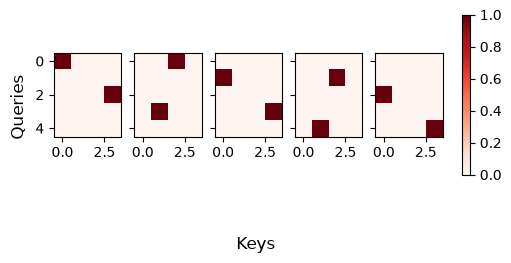

In [3]:
attention_weights = torch.eye(10).reshape((1, 5, 5, 4))
show_heatmaps(attention_weights, xlabel="Keys", ylabel="Queries", figsize=(5, 3))

## Masked Softmax


In [4]:
import torch


def masked_softmax(X, valid_lens=None):
    """Perform softmax while masking out invalid positions.

    Args:
        X: Tensor of shape (batch_size, num_queries, num_kv)
           or (batch_size, num_kv)
        valid_lens: Tensor of shape (batch_size,) or
                    (batch_size, num_queries)

    Returns:
        Tensor with the same shape as X.
    """

    def _sequence_mask(X, valid_lens, value=-1e6):
        max_len = X.shape[-1]
        mask = torch.arange(max_len, device=X.device)[None, :] < valid_lens[:, None]
        X[~mask] = value
        return X

    shape = X.shape

    if valid_lens is None:
        return torch.softmax(X, dim=1)
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)

    X = X.reshape(-1, shape[-1])
    X = _sequence_mask(X, valid_lens)

    return torch.softmax(X.reshape(shape), dim=-1)


masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.4071, 0.1853, 0.4077, 0.0000]],

        [[0.5929, 0.4071, 0.0000, 0.0000],
         [0.2695, 0.2202, 0.2581, 0.2522]]])

## Dot Product Attention


In [5]:
import math
from torch import nn


class DotProductAttention(nn.Module):
    def __init__(self, dropout) -> None:
        super().__init__()

        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        # Shape of queries: (batch_size, no. of queries, d)
        # Shape of keys: (batch_size, no. of key-value pairs, d)
        # Shape of values: (batch_size, no. of key-value pairs, value dimension)
        # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = self.masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

    def masked_softmax(self, X, valid_lens=None):
        """Perform softmax while masking out invalid positions.

        Args:
            X: Tensor of shape (batch_size, num_queries, num_kv)
            or (batch_size, num_kv)
            valid_lens: Tensor of shape (batch_size,) or
                        (batch_size, num_queries)

        Returns:
            Tensor with the same shape as X.
        """

        def _sequence_mask(X, valid_lens, value=-1e6):
            max_len = X.shape[-1]
            mask = torch.arange(max_len, device=X.device)[None, :] < valid_lens[:, None]
            X[~mask] = value
            return X

        shape = X.shape

        if valid_lens is None:
            return torch.softmax(X, dim=1)
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = X.reshape(-1, shape[-1])
        X = _sequence_mask(X, valid_lens)

        return torch.softmax(X.reshape(shape), dim=-1)

In [6]:
queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 1.9094,  0.5405,  1.3448,  1.3091]],

        [[-0.1190, -0.2977,  0.3856, -0.0924]]])

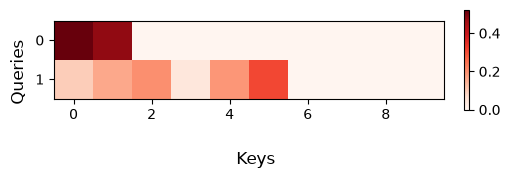

In [7]:
show_heatmaps(
    attention.attention_weights.reshape((1, 1, 2, 10)),
    xlabel="Keys",
    ylabel="Queries",
    figsize=(5, 2),
)

In [8]:
attention.attention_weights

tensor([[[0.5229, 0.4771, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.0992, 0.1595, 0.2008, 0.0436, 0.1879, 0.3089, 0.0000, 0.0000,
          0.0000, 0.0000]]])

## Additive Attention

$$
a(\mathbf{q}, \mathbf{k}) =
\mathbf{w}_v^\top
\tanh\left(
\mathbf{W}_q\mathbf{q}
+
\mathbf{W}_k\mathbf{k}
\right)
\in \mathbb{R}
$$


## Multihead Attention


In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, num_hiddens, dropout, bias=False) -> None:
        super().__init__()

        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.Wq = nn.LazyLinear(num_hiddens, bias=bias)
        self.Wk = nn.LazyLinear(num_hiddens, bias=bias)
        self.Wv = nn.LazyLinear(num_hiddens, bias=bias)
        self.Wo = nn.LazyLinear(num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        q = self.transpose_qkv(self.Wq(queries))
        k = self.transpose_qkv(self.Wk(keys))
        v = self.transpose_qkv(self.Wv(values))

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, self.num_heads, dim=0)

        output = self.attention(q, k, v, valid_lens)
        output_concat = self.transpose_output(output)
        return self.Wo(output_concat)

    def transpose_qkv(self, x):
        # Initial shape : (batch size, no. of queries or kv, hidden)
        # Converted shape : (batch size, no.of queries, heads, hidden/heads)
        x = x.reshape(x.shape[0], x.shape[1], self.num_heads, -1)
        # Switch dimensions (batch size, heads, no. of queries, hidden/heads)
        x = x.permute(0, 2, 1, 3)
        # make the dimesion (batch size * heads, no. of queries hidden/heads)
        # to easily feed to torch.bmm which expects the tensor of shape (batch, m1, m2)
        return x.reshape(-1, x.shape[2], x.shape[3])

    def transpose_output(self, x):
        """Reverse the operation of transpose_qkv"""
        x = x.reshape(-1, self.num_heads, x.shape[1], x.shape[2])
        x = x.permute(0, 2, 1, 3)
        return x.reshape(x.shape[0], x.shape[1], -1)

In [10]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_heads, num_hiddens, 0.5)
batch_size, num_queries, num_kvpairs = 2, 4, 6
valid_lens = torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))

attention.eval()
attention(X, Y, Y, valid_lens)

tensor([[[ 1.5337e-01,  6.3972e-01,  9.5185e-02, -2.5289e-01,  1.9020e-01,
           1.5650e-01,  3.2185e-02,  7.5661e-01, -8.0496e-01,  2.7329e-01,
           5.4675e-01,  3.7244e-02, -2.7308e-01,  4.3788e-01, -1.4036e-01,
          -2.5777e-01, -5.5076e-01,  6.6688e-02,  9.7071e-03,  8.3400e-01,
          -4.4958e-01,  1.1827e-01,  4.3661e-01, -7.4466e-02,  5.7354e-02,
           3.1722e-01, -7.9788e-01,  6.7584e-02,  1.9837e-01, -2.3567e-01,
          -2.2158e-02,  2.9014e-01,  1.0416e-01,  7.1998e-03, -4.0661e-01,
           1.8576e-01, -2.2899e-02, -4.1355e-02, -3.0991e-01,  3.9214e-01,
           1.9476e-01,  7.8438e-04,  1.5883e-01,  4.5121e-02,  1.6788e-01,
           4.6378e-01,  2.7036e-01, -3.7758e-01,  2.8370e-01,  2.8998e-01,
          -1.7641e-01,  4.5268e-01,  4.3964e-01, -6.0543e-01, -6.4707e-01,
           4.8135e-01,  6.7088e-01,  2.4466e-01, -1.8020e-01, -4.6721e-01,
          -2.3832e-02, -2.0643e-01, -5.6195e-01,  2.2308e-01, -1.6174e-01,
           3.4335e-01,  1

## Self Attention


In [11]:
num_heads, num_hiddens = 100, 5
attention = MultiHeadAttention(num_hiddens, num_heads, 0.5)

batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
X = torch.ones(batch_size, num_queries, num_hiddens)

attention(X, X, X, valid_lens)

tensor([[[ 3.0422e-01,  7.4121e-01,  8.9512e-02, -8.5751e-01, -3.0085e-01,
          -9.5013e-01, -7.0758e-01, -1.0394e+00,  4.3694e-01, -8.4152e-02,
           2.5477e-01,  3.3329e-01, -3.9616e-01,  1.3764e-01, -9.8037e-02,
          -4.9267e-02,  9.1235e-02,  4.8548e-01,  7.5172e-01, -5.4665e-01,
          -2.4811e-01, -1.3408e-01,  2.6912e-02, -5.3858e-01,  2.4801e-01,
          -4.3434e-01, -7.3863e-01,  1.0728e-01,  2.2204e-01, -2.3125e-01,
           6.6858e-01,  8.4407e-01, -6.8868e-01,  1.0021e+00, -5.3039e-01,
           4.5328e-01, -4.0395e-01,  6.6459e-01, -7.3533e-02, -2.3986e-01,
          -3.7455e-01, -3.1745e-01, -1.3184e-02, -4.8255e-01, -5.4164e-01,
           3.2138e-02,  6.8555e-01,  4.1054e-01,  3.4902e-01, -6.0416e-01,
          -2.6527e-01,  2.6468e-02,  2.7933e-01, -8.4756e-02,  1.7436e-01,
          -1.3987e-01,  8.3832e-02,  2.3829e-01, -6.1020e-01, -1.0157e+00,
           1.0498e-01, -3.6188e-02, -5.3809e-01,  2.7372e-01, -1.1042e-01,
           1.7535e-01,  1

## Positional Encoding


In [12]:
class PositionalEncoding(nn.Module):

    def __init__(self, num_hiddens, dropout, max_len=1000) -> None:
        super().__init__()

        self.dropout = nn.Dropout(dropout)
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32)[:, None] / torch.pow(
            10000, torch.arange(0, num_hiddens, 2) / num_hiddens
        )
        self.P[:, :, ::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, x):
        x = x + self.P[:, : x.shape[1], :].to(x.device)
        return self.dropout(x)

Text(0, 0.5, 'Encoding value')

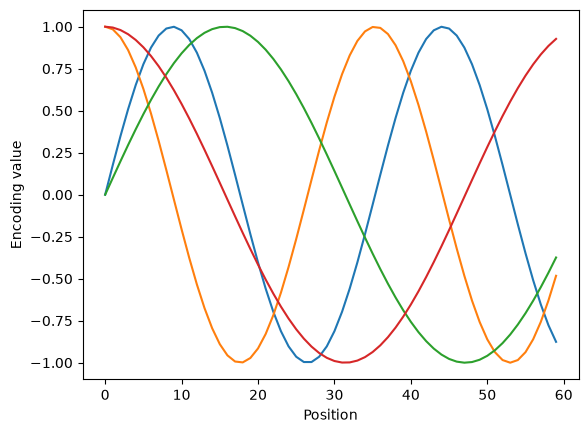

In [13]:
encoding_dim, num_steps = 32, 60
pos_encoding = PositionalEncoding(encoding_dim, 0)
X = pos_encoding(torch.zeros((1, num_steps, encoding_dim)))
P = pos_encoding.P[:, : X.shape[1], :]
plt.plot(
    torch.arange(num_steps),
    P[0, :, 6:10],
)

plt.xlabel("Position")
plt.ylabel("Encoding value")

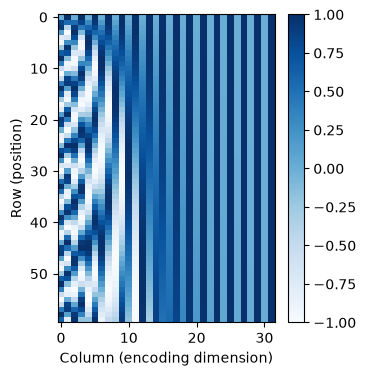

In [14]:
P = pos_encoding.P[:, :num_steps, :]

plt.figure(figsize=(3.5, 4))
plt.imshow(P[0].detach().numpy(), aspect="auto", cmap="Blues")

plt.xlabel("Column (encoding dimension)")
plt.ylabel("Row (position)")
plt.colorbar()

plt.show()

## Transformer Architecture


### Position Wise FFN


In [15]:
class PositionWiseFFN(nn.Module):
    def __init__(self, ffn_num_hiddens, ffn_num_outputs) -> None:
        super().__init__()

        self.ffn = nn.Sequential(
            nn.LazyLinear(ffn_num_hiddens), nn.ReLU(), nn.LazyLinear(ffn_num_outputs)
        )

    def forward(self, x):
        return self.ffn(x)

### Residual Connection & Normalization


In [16]:
class AddNorm(nn.Module):

    def __init__(self, norm_shape, dropout) -> None:
        super().__init__()

        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(norm_shape)

    def forward(self, X, y):
        return self.ln(self.dropout(y) + X)

In [17]:
add_norm = AddNorm(4, 0.5)
shape = (2, 3, 4)
summary(AddNorm(4, 0.5), ((2, 3, 4), (2, 3, 4)))

Layer (type:depth-idx)                   Output Shape              Param #
AddNorm                                  [2, 3, 4]                 --
├─Dropout: 1-1                           [2, 3, 4]                 --
├─LayerNorm: 1-2                         [2, 3, 4]                 8
Total params: 8
Trainable params: 8
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### Encoder


In [18]:
class TransformerEncoderBlock(nn.Module):

    def __init__(
        self, num_hiddens, ffn_num_hiddens, num_heads, dropout, bias=False
    ) -> None:
        super().__init__()

        self.attention = MultiHeadAttention(num_heads, num_hiddens, dropout, bias=bias)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, x, valid_lens):
        y = self.addnorm1(x, self.attention(x, x, x, valid_lens))
        return self.addnorm2(y, self.ffn(y))

In [19]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = TransformerEncoderBlock(24, 48, 8, 0.5)
encoder_blk.eval()
encoder_blk(X, valid_lens)

tensor([[[ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         ...,
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273]],

        [[ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         ...,
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273],
         [ 1.1911,  0.5937, -0.8002,  ...,  0.7262,  0.0875, -2.1273]]],
       grad_fn=<NativeLayerNormBackward0>)

In [20]:
import math


class TransformerEncoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        num_hiddens,
        ffn_num_hiddens,
        num_heads,
        num_blks,
        dropout,
        bias=False,
    ) -> None:
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(
                f"block{i}",
                TransformerEncoderBlock(
                    num_hiddens, ffn_num_hiddens, num_heads, dropout, bias=bias
                ),
            )

    def forward(self, x, valid_lens):
        x = self.pos_encoding(self.embedding(x) * math.sqrt(num_hiddens))
        self.attention_weights = []
        for blk in self.blks:
            x = blk(x, valid_lens)
            self.attention_weights.append(blk.attention.attention.attention_weights)
        return x

In [21]:
encoder = TransformerEncoder(200, 24, 48, 8, 2, 0.5)

X = torch.ones((2, 100), dtype=torch.long)
valid_lens = torch.tensor([100, 100])

encoder(X, valid_lens)

tensor([[[-0.0837,  1.9967,  0.0809,  ...,  0.6624, -0.5910, -1.8189],
         [-0.1536, -0.3451, -0.7598,  ...,  1.0428, -0.2138, -0.4937],
         [ 0.3899,  0.5134, -0.6097,  ...,  0.6776, -0.6304,  0.8036],
         ...,
         [-0.0171,  0.0378, -0.2051,  ...,  1.0313,  0.5711, -0.1936],
         [-1.1217,  0.9729, -0.8846,  ...,  0.0280, -0.6077, -0.4864],
         [-0.8914,  2.3369,  0.0576,  ..., -0.3289,  0.0834, -1.3192]],

        [[ 0.0485,  1.7310, -0.4377,  ..., -0.3166,  0.1754, -0.2413],
         [-0.5030,  1.7925, -0.3367,  ...,  0.6020, -1.6271,  1.2720],
         [-0.6186,  2.7931, -0.6191,  ...,  0.8407, -0.8825,  1.0690],
         ...,
         [-0.2276,  1.5383,  0.1577,  ...,  0.0395,  0.2685,  0.2406],
         [-0.4169, -0.9518, -0.2319,  ...,  0.2878, -0.2990, -0.3842],
         [-0.9571,  2.0897, -0.3117,  ...,  0.4829, -0.8694, -0.9015]]],
       grad_fn=<NativeLayerNormBackward0>)

In [22]:
encoder = TransformerEncoder(200, 24, 48, 8, 2, 0.5)

X = torch.ones((2, 100), dtype=torch.long)
valid_lens = torch.tensor([100, 100])

summary(encoder, input_data=(X, valid_lens))

Layer (type:depth-idx)                             Output Shape              Param #
TransformerEncoder                                 [2, 100, 24]              --
├─Embedding: 1-1                                   [2, 100, 24]              4,800
├─PositionalEncoding: 1-2                          [2, 100, 24]              --
│    └─Dropout: 2-1                                [2, 100, 24]              --
├─Sequential: 1-3                                  --                        --
│    └─TransformerEncoderBlock: 2-2                [2, 100, 24]              --
│    │    └─MultiHeadAttention: 3-1                [2, 100, 24]              2,304
│    │    └─AddNorm: 3-2                           [2, 100, 24]              48
│    │    └─PositionWiseFFN: 3-3                   [2, 100, 24]              2,376
│    │    └─AddNorm: 3-4                           [2, 100, 24]              48
│    └─TransformerEncoderBlock: 2-3                [2, 100, 24]              --
│    │    └─MultiHeadAtten

### Decoder


In [23]:
class TransformerDecoderBlock(nn.Module):
    # The i-th block in the Transformer decoder
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, i):
        super().__init__()
        self.i = i

        self.attention1 = MultiHeadAttention(num_heads, num_hiddens, dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)

        self.attention2 = MultiHeadAttention(num_heads, num_hiddens, dropout)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(num_hiddens, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]

        # during training all the tokens of any output sequence are processed
        # at the same time, so state[2][self.i] is None as initialized.
        # When decoding any output sequence token by token during prediction,
        # state[2][self.i] contains representations of the decoded output at
        # the i-th block up to the current time step
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), dim=1)

        state[2][self.i] = key_values

        if self.training:
            batch_size, num_steps, _ = X.shape

            # Shape of dec_valid_lens: (batch_size, num_steps), where every row is [1, 2, ..., num_steps]
            dec_valid_lens = torch.arange(1, num_steps + 1, device=X.device).repeat(
                batch_size, 1
            )
        else:
            dec_valid_lens = None

        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)

        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)

        return self.addnorm3(Z, self.ffn(Z)), state

In [24]:
class TransformerDecoder(nn.Module):
    def __init__(
        self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout
    ):
        super().__init__()

        self.num_hiddens = num_hiddens
        self.num_blks = num_blks

        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)

        self.blks = nn.Sequential()

        for i in range(num_blks):
            self.blks.add_module(
                "block" + str(i),
                TransformerDecoderBlock(
                    num_hiddens, ffn_num_hiddens, num_heads, dropout, i
                ),
            )

        self.dense = nn.LazyLinear(vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        return [enc_outputs, enc_valid_lens, [None] * self.num_blks]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))

        self._attention_weights = [[None] * len(self.blks) for _ in range(2)]

        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)

            self._attention_weights[0][i] = blk.attention1.attention.attention_weights

            self._attention_weights[1][i] = blk.attention2.attention.attention_weights

        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

## Training


### Make the Dataset


In [25]:
import urllib.request
import zipfile
from pathlib import Path

url = "http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip"

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

zip_path = data_dir / "fra-eng.zip"

if not zip_path.exists():
    urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(data_dir)

file_path = data_dir / "fra-eng" / "fra.txt"

with open(file_path, encoding="utf-8") as f:
    text = f.read()

print(text[:500])

Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !
Fire!	Au feu !
Help!	À l'aide !
Jump.	Saute.
Stop!	Ça suffit !
Stop!	Stop !
Stop!	Arrête-toi !
Wait!	Attends !
Wait!	Attendez !
Go on.	Poursuis.
Go on.	Continuez.
Go on.	Poursuivez.
Hello!	Bonjour !
Hello!	Salut !
I see.	Je comprends.
I try.	J'essaye.
I won!	J'ai gagné !
I won!	Je l'ai emporté !
I won.	J’ai gagné.
Oh no!	Oh non !
Attack!	Attaque !
Attack!	Attaquez !
Cheers!	Santé !
Cheers!	À votre santé !
Cheers!	Merci !



In [26]:
def preprocess(text):
    text = text.replace("\u202f", " ")
    text = text.replace("\xa0", " ")
    text = text.lower()

    result = []

    for i, char in enumerate(text):
        if char in ",.!?" and i > 0 and text[i - 1] != " ":
            result.append(" ")

        result.append(char)

    return "".join(result)


text = preprocess(text)

In [27]:
def tokenize(text, max_examples=None):
    src = []
    tgt = []

    lines = text.split("\n")

    for i, line in enumerate(lines):
        if max_examples is not None and i >= max_examples:
            break

        parts = line.split("\t")

        if len(parts) != 2:
            continue

        src_sentence = parts[0].split()
        tgt_sentence = parts[1].split()

        src_sentence.append("<eos>")
        tgt_sentence.append("<eos>")

        src.append(src_sentence)
        tgt.append(tgt_sentence)

    return src, tgt

In [28]:
from collections import Counter


class Vocab:
    def __init__(self, sentences, min_freq=2):
        counter = Counter()

        for sentence in sentences:
            counter.update(sentence)

        tokens = [token for token, freq in counter.items() if freq >= min_freq]

        special_tokens = ["<unk>", "<pad>", "<bos>", "<eos>"]

        self.idx_to_token = special_tokens + sorted(tokens)

        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

        self.unk = self.token_to_idx["<unk>"]

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, token):
        if isinstance(token, list):
            return [self[token] for token in token]

        return self.token_to_idx.get(token, self.unk)

    def to_tokens(self, indices):
        return [self.idx_to_token[int(i)] for i in indices]

In [29]:
def build_array(sentences, vocab, num_steps, is_target=False):
    arrays = []
    valid_lens = []

    for sentence in sentences:

        sentence = sentence[:num_steps]

        if is_target:
            sentence = ["<bos>"] + sentence

        if len(sentence) < num_steps + int(is_target):
            sentence += ["<pad>"] * (num_steps + int(is_target) - len(sentence))

        ids = vocab[sentence]

        arrays.append(ids)

        valid_len = sum(token != vocab["<pad>"] for token in ids)

        valid_lens.append(valid_len)

    return (
        torch.tensor(arrays, dtype=torch.long),
        torch.tensor(valid_lens, dtype=torch.long),
    )

In [30]:
src_sentences, tgt_sentences = tokenize(text, max_examples=640)

src_vocab = Vocab(src_sentences, min_freq=2)
tgt_vocab = Vocab(tgt_sentences, min_freq=2)

print("Source vocab:", len(src_vocab))
print("Target vocab:", len(tgt_vocab))

Source vocab: 196
Target vocab: 214


In [31]:
def build_array(sentences, vocab, num_steps, is_target=False):
    arrays = []
    valid_lens = []

    for sentence in sentences:

        sentence = sentence[:num_steps]

        if is_target:
            sentence = ["<bos>"] + sentence

        if len(sentence) < num_steps + int(is_target):
            sentence += ["<pad>"] * (num_steps + int(is_target) - len(sentence))

        ids = vocab[sentence]

        arrays.append(ids)

        valid_len = sum(token != vocab["<pad>"] for token in ids)

        valid_lens.append(valid_len)

    return (
        torch.tensor(arrays, dtype=torch.long),
        torch.tensor(valid_lens, dtype=torch.long),
    )

In [32]:
NUM_STEPS = 9

src, src_valid_len = build_array(src_sentences, src_vocab, NUM_STEPS, is_target=False)

tgt_full, _ = build_array(tgt_sentences, tgt_vocab, NUM_STEPS, is_target=True)

tgt = tgt_full[:, :-1]
label = tgt_full[:, 1:]

print(src.shape)
print(src_valid_len.shape)
print(tgt.shape)
print(label.shape)

torch.Size([640, 9])
torch.Size([640])
torch.Size([640, 9])
torch.Size([640, 9])


In [33]:
from torch.utils.data import TensorDataset, DataLoader

num_train = 512

train_dataset = TensorDataset(
    src[:num_train], tgt[:num_train], src_valid_len[:num_train], label[:num_train]
)

val_dataset = TensorDataset(
    src[num_train:], tgt[num_train:], src_valid_len[num_train:], label[num_train:]
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

for src, tgt, src_valid_len, label in train_loader:
    print(src.shape)
    print(tgt.shape)
    print(src_valid_len.shape)
    print(label.shape)
    break

torch.Size([128, 9])
torch.Size([128, 9])
torch.Size([128])
torch.Size([128, 9])


### Seq 2 Seq Model


In [34]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, src_valid_len):
        enc_outputs = self.encoder(src, src_valid_len)

        state = self.decoder.init_state(enc_outputs, src_valid_len)

        logits, state = self.decoder(tgt, state)

        return logits

In [35]:
NUM_HIDDENS = 256
NUM_BLKS = 2
DROPOUT = 0.2
FFN_NUM_HIDDENS = 64
NUM_HEADS = 4

encoder = TransformerEncoder(
    vocab_size=len(src_vocab),
    num_hiddens=NUM_HIDDENS,
    ffn_num_hiddens=FFN_NUM_HIDDENS,
    num_heads=NUM_HEADS,
    num_blks=NUM_BLKS,
    dropout=DROPOUT,
)

decoder = TransformerDecoder(
    vocab_size=len(tgt_vocab),
    num_hiddens=NUM_HIDDENS,
    ffn_num_hiddens=FFN_NUM_HIDDENS,
    num_heads=NUM_HEADS,
    num_blks=NUM_BLKS,
    dropout=DROPOUT,
)

model = Seq2Seq(encoder, decoder)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(DEVICE)

print(f"Using device: {DEVICE}")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

Using device: cuda


In [36]:
def train_transformer(dataloader, model, optimizer, loss_fn, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()
    train_loss = 0

    for batch, (src, tgt, src_valid_len, label) in enumerate(dataloader):
        src = src.to(device)
        tgt = tgt.to(device)
        src_valid_len = src_valid_len.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        logits = model(src, tgt, src_valid_len)
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), label.reshape(-1))
        train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        if batch % 100 == 0:
            print(
                f"Loss : {loss.item():>7f} " f"[{(batch + 1) * len(src):>5d} / {size}]"
            )
    if batch % 100 != 0:
        print(
            f"Loss : {loss.item():>7f} " f"[{(batch + 1) * len(src):>5d} / {size:>5d}]"
        )

    return train_loss / num_batches


def test_transformer(dataloader, model, loss_fn, device):
    num_batches = len(dataloader)

    model.eval()
    test_loss = 0

    with torch.no_grad():
        for src, tgt, src_valid_len, label in dataloader:
            src = src.to(device)
            tgt = tgt.to(device)
            src_valid_len = src_valid_len.to(device)
            label = label.to(device)

            logits = model(src, tgt, src_valid_len)
            loss = loss_fn(logits.reshape(-1, logits.shape[-1]), label.reshape(-1))

            test_loss += loss.item()

    test_loss /= num_batches

    print(f"Test Error :\n" f" Avg Loss : {test_loss:>7f} |\n")

    return test_loss


def plot_net(data_dict):
    plt.figure(figsize=(8, 5))

    for label, values in data_dict.items():
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=label)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

Epoch 1----------------------------------------------
Loss : 5.668798 [  128 / 512]
Loss : 2.112792 [  512 /   512]
Test Error :
 Avg Loss : 2.326670 |

Epoch 2----------------------------------------------
Loss : 1.908279 [  128 / 512]
Loss : 1.462227 [  512 /   512]
Test Error :
 Avg Loss : 1.832045 |

Epoch 3----------------------------------------------
Loss : 1.347512 [  128 / 512]
Loss : 1.073385 [  512 /   512]
Test Error :
 Avg Loss : 1.643679 |

Epoch 4----------------------------------------------
Loss : 1.035825 [  128 / 512]
Loss : 1.059156 [  512 /   512]
Test Error :
 Avg Loss : 1.610047 |

Epoch 5----------------------------------------------
Loss : 0.919641 [  128 / 512]
Loss : 0.959174 [  512 /   512]
Test Error :
 Avg Loss : 1.552354 |

Epoch 6----------------------------------------------
Loss : 0.889380 [  128 / 512]
Loss : 0.845119 [  512 /   512]
Test Error :
 Avg Loss : 1.522976 |

Epoch 7----------------------------------------------
Loss : 0.811714 [  128 / 512

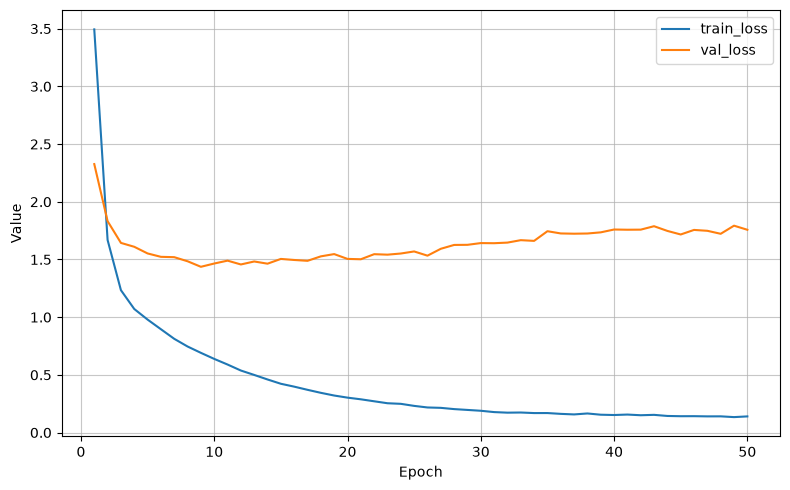

In [37]:
history = {"train_loss": [], "val_loss": []}

EPOCHS = 50

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}" "----------------------------------------------")

    train_loss = train_transformer(train_loader, model, optimizer, loss_fn, DEVICE)

    val_loss = test_transformer(val_loader, model, loss_fn, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

plot_net(history)

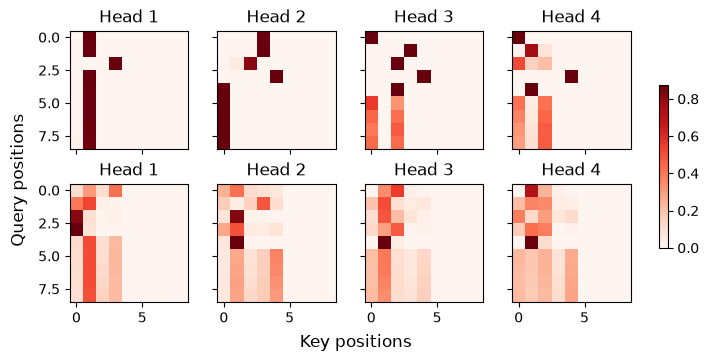

In [38]:
shape = (NUM_BLKS, NUM_HEADS, -1, NUM_STEPS)
enc_attention_weights = torch.cat(model.encoder.attention_weights, 0)
enc_attention_weights = enc_attention_weights.reshape(
    NUM_BLKS, NUM_HEADS, -1, NUM_STEPS, NUM_STEPS
)
enc_attention_weights = enc_attention_weights[:, :, 0]

show_heatmaps(
    enc_attention_weights.cpu(),
    xlabel="Key positions",
    ylabel="Query positions",
    titles=["Head %d" % i for i in range(1, 5)],
    figsize=(7, 3.5),
)